# Deep Learning with PyTorch

In the previous notebook we trained traditional ML models (Ridge, Lasso, RandomForest, GradientBoosting) and achieved an R² of ~0.87 on the test set with GradientBoosting. Here we explore whether a neural network can improve upon those results.

Neural networks can capture complex non-linear relationships without explicit feature engineering. However, for tabular data, they often perform comparably to (or worse than) well-tuned gradient boosting. This notebook serves as a practical introduction to building regression models with PyTorch.

## Load preprocessed data

In [ ]:
import numpy as np
from pathlib import Path

data_dir = Path("processed_data")

X_train = np.load(data_dir / "X_train.npy")
X_val = np.load(data_dir / "X_val.npy")
X_test = np.load(data_dir / "X_test.npy")
y_train = np.load(data_dir / "y_train.npy")
y_val = np.load(data_dir / "y_val.npy")
y_test = np.load(data_dir / "y_test.npy")
feature_names = np.load(data_dir / "feature_names.npy", allow_pickle=True)

n_features = X_train.shape[1]
print(f"Training set:   {X_train.shape[0]:,} samples, {n_features} features")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")

Training set:   15,129 samples, 22 features
Validation set: 3,242 samples
Test set:       3,242 samples


## Target scaling


Unlike tree-based models, neural networks are sensitive to the scale of the target variable. With raw house prices (~$100k–$2M), the MSE loss is on the order of $10^{11}$, causing gradient instability (large, erratic updates), slow convergence, and noisy loss curves.

Tree-based models split on feature thresholds and never compute gradients, so they are unaffected by target scale. Neural networks, on the other hand, benefit greatly from having the target in a normalized range.

We fit a `StandardScaler` on `y_train` only (to avoid data leakage), use scaled targets during training, and **inverse-transform predictions back to dollar values** before computing evaluation metrics.


In [ ]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1))
# fit_transform already returns shape (n, 1)

print(f"y_train — mean: ${y_train.mean():,.0f}, std: ${y_train.std():,.0f}")
print(f"y_train_scaled — mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")


y_train — mean: $538,936, std: $369,699
y_train_scaled — mean: 0.0000, std: 1.0000


## Evaluation metrics

We reuse the same evaluation function from notebook 05 to ensure comparable results.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, set_name: str = "Set") -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{set_name}:")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape}

## PyTorch setup

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Prepare DataLoaders

PyTorch works with tensors, not numpy arrays. We convert the data and wrap it in `DataLoader` objects for batched training.

The features (X) are already scaled (from notebook 04b). For the target `y` we use the scaled versions from the previous section (`y_train_scaled`, `y_val_scaled`, `y_test_scaled`).

In [ ]:
# Convert to float32 tensors (PyTorch default precision)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# No reshape needed: already (n, 1) from the scaler
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# shuffle=True only for training; validation and test order doesn't matter but we keep it deterministic
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Training batches: {len(train_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Training batches: 60
Batch size: 256


## Model definition

We define a simple fully-connected (dense) network. For tabular regression:
- A few hidden layers with decreasing width is a common architecture
- **Batch Normalization** helps stabilize and speed up training
- **Dropout** provides regularization to prevent overfitting
- **ReLU** activations introduce non-linearity
- The output layer has a single neuron (regression target: price) with **no activation** (we want unbounded predictions)

In [ ]:
class HousePriceNet(nn.Module):
    def __init__(self, n_features: int, dropout_rate: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # Less dropout near the output

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


model = HousePriceNet(n_features).to(device)
display(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

HousePriceNet(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)


Total parameters: 48,001


## Training configuration

Key training decisions:

- **Loss: MSE on the scaled target**
We minimize Mean Squared Error on the StandardScaler-normalized target. After StandardScaler, y has mean = 0 and std = 1. MSE is the average of squared errors in that scaled space. So:
    - MSE = 1.0 means the average squared error equals 1² = 1 variance unit, i.e. the model is no better than predicting the mean.
    - MSE = 0.0 would be a perfect fit.
    - In practice a well-trained model lands somewhere in (0, 1), often 0.1–0.5., MSE would be around $10^{11}$, producing enormous gradients that destabilize training.

- **Optimizer: Adam with weight decay**
Adam maintains per-parameter adaptive learning rates by tracking moving averages of past gradients, resulting in faster and more stable convergence than plain SGD. `weight_decay=1e-4` adds L2 regularization: large weights are penalized, which discourages overfitting.

- **Early stopping**
We track the best validation loss observed so far (`best_val_loss`) and save the model weights at that point (`best_state`):
    - If the current epoch's loss improves → update `best_val_loss`, overwrite `best_state`, reset counter to 0
    - Otherwise → increment `epochs_without_improvement`
    - When `epochs_without_improvement == PATIENCE` → stop training and restore `best_state`

This ensures we return the model that generalized *best* on the validation set — not the last epoch, which may have slightly overfit. It also saves compute time: once the model stops improving, further training is wasteful.


In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 300
PATIENCE = 15  # Early stopping patience

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training loop

Unlike sklearn's `.fit()`, PyTorch requires writing the training loop explicitly. This is more code, but gives full visibility into what is happening.

Each epoch has three phases:

1. **Training phase** (`model.train()`): iterate over mini-batches — forward pass, compute MSE loss on scald targets, backpropagate gradients, update weights with Adam.
2. **Validation phase** (`model.eval()`): compute MSE loss and collect all predictions without gradient tracking. Also inverse-transform predictions back to dollars and compute RMSE.
3. **Extra train forward pass** (eval mode, no gradients): compute train RMSE in dollars. This extra pass is needed because during training the model was in `model.train()` mode (Dropout active), which would give an artificially higher and noisier RMSE.

The `model.train()` / `model.eval()` toggle is critical: it controls the behavior of **Dropout** (active only during training) and **BatchNorm** (uses per-batch statistics during training, running mean/variance during evaluation). This is why training loss can appear *higher* than validation loss even when the model is learning well — Dropout randomly masks neurons during training, making every forward pass harder.


In [ ]:
train_losses = []
val_losses = []
val_rmses = []
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        n_batches += 1

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # --- Validation phase ---
    model.eval()
    running_val_loss = 0.0
    n_val_batches = 0
    all_val_preds = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
            n_val_batches += 1
            all_val_preds.append(predictions.cpu())  # collect for RMSE

    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    # Validation RMSE in dollars (inverse-transform to original target scale)
    val_preds_scaled = torch.cat(all_val_preds).numpy()
    val_preds_dollars = y_scaler.inverse_transform(val_preds_scaled).squeeze()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds_dollars))
    val_rmses.append(val_rmse)


    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        # Save best model weights
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 25 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val RMSE: ${val_rmse:,.0f} | "
            f"LR: {current_lr:.1e}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch+1}")
print(f"Best validation RMSE: ${val_rmses[best_epoch]:,.0f}")


Epoch   1/300 | Train Loss: 0.3816 | Val Loss: 0.2461 | Val RMSE: $183,394 | LR: 1.0e-03
Epoch  25/300 | Train Loss: 0.1353 | Val Loss: 0.1392 | Val RMSE: $137,910 | LR: 1.0e-03
Epoch  50/300 | Train Loss: 0.1121 | Val Loss: 0.1121 | Val RMSE: $123,767 | LR: 1.0e-03

Early stopping at epoch 71. Best epoch: 56

Restored best model from epoch 56
Best validation RMSE: $119,993


## Learning curves

We use two complementary views to monitor training:

1. **MSE loss** — the signal the optimizer actually minimizes. Values are dimensionless (on the scaled target), which makes them stable and comparable across runs, but hard to interpret in business terms.
2. **RMSE in dollars** — the same error expressed in the original target units ($). This makes the numbers meaningful: we can directly compare against the baseline models from notebook 05.


### MSE loss: the optimization view


The MSE loss is computed on the **scaled** target (standardized to mean ≈ 0, std ≈ 1). A value of 1.0 means the average squared error equals the variance of the target — essentially no better than predicting the mean. A well-trained model should reach values well below 1.0.

**Note on train > val loss:** With Dropout and BatchNorm active during training, the training MSE is typically *higher* than the validation MSE — this is expected and not a sign of underfitting. Both layers are disabled during evaluation, making the forward pass deterministic and slightly easier.


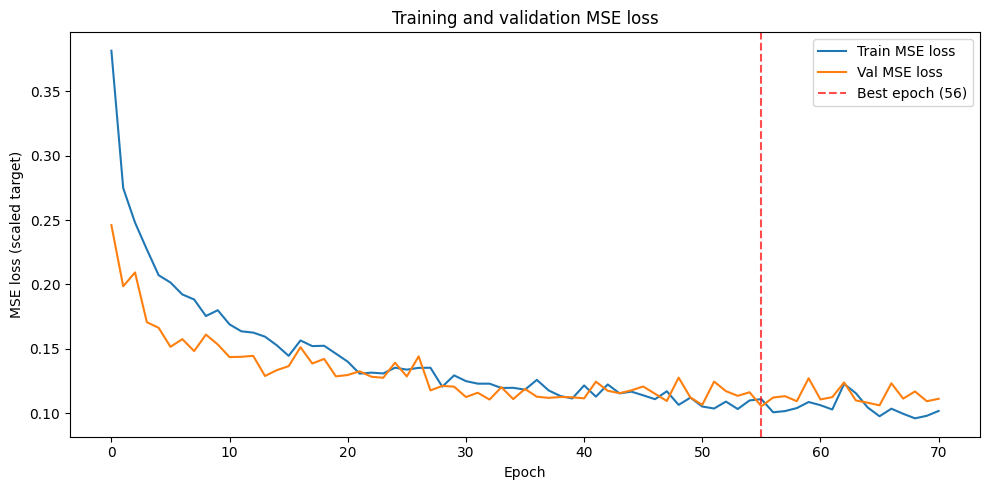

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train MSE loss")
ax.plot(val_losses, label="Val MSE loss")
ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch + 1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (scaled target)")
ax.set_title("Training and validation MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

What to look for in this plot:
- **Both curves decreasing together**: the model is learning and generalizing.
- **Red dashed line (best epoch)**: where early stopping saved the weights — the point before overfitting began.
- **Train loss ≥ val loss**: normal with Dropout/BatchNorm as explained above.
- **Val loss flattening then rising slightly**: the optimizer is starting to fit training noise; early stopping prevents this.


### RMSE in dollars: the interpretability view


Here we track the same validation predictions, but with the scaler reversed so the error is expressed in dollars. This curve answers the practical question: *"On average, how far off is the model's price prediction?"*

The red dashed line marks the best epoch — the weights restored at the end of training. The RMSE at that epoch is the number we compare against baseline models.


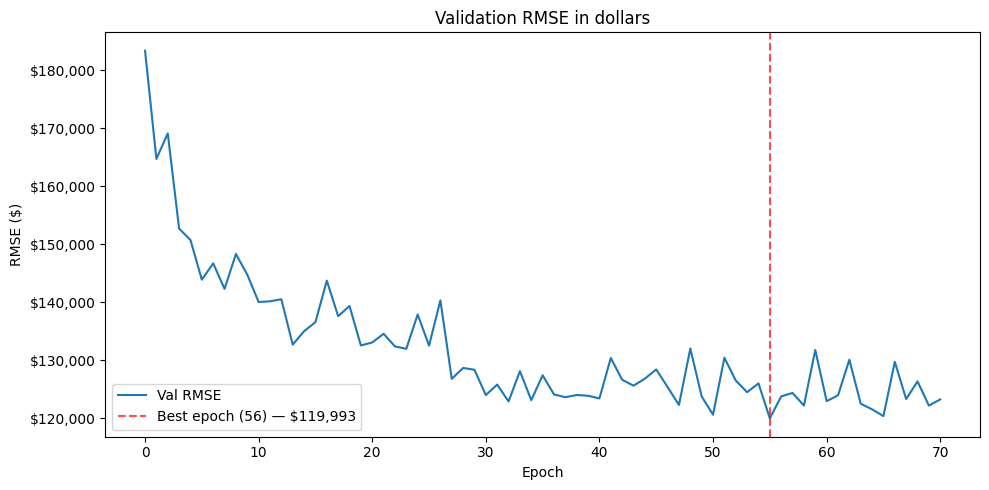

In [ ]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_rmses, label="Val RMSE")
ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch + 1}) — ${val_rmses[best_epoch]:,.0f}")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE ($)")
ax.set_title("Validation RMSE in dollars")
ax.legend()
plt.tight_layout()
plt.show()


The label on the best-epoch marker shows the validation RMSE in dollars at that point. Compare this to the baseline models in the comparison section — if the neural network is competitive, the RMSE should be in the same ballpark as Gradient Boosting (~$136k from notebook 05).

A decreasing RMSE curve that levels off is the healthy pattern: the model improves quickly in early epochs, then gains diminish as it approaches the best achievable fit on this architecture and dataset.


## Evaluation

To generate predictions, we run the model in evaluation mode (`model.eval()`) with gradient computation disabled (`torch.no_grad()`). This is faster and ensures BatchNorm/Dropout behave correctly for inference.

In [ ]:
@torch.no_grad()
def predict(model: nn.Module, dataloader: DataLoader) -> np.ndarray:
    """Run inference and inverse-transform predictions back to dollar values."""
    model.eval()
    predictions = []
    for X_batch, _ in dataloader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        predictions.append(preds.cpu().numpy())
    scaled_preds = np.concatenate(predictions).reshape(-1, 1)
    return y_scaler.inverse_transform(scaled_preds).squeeze()

In [ ]:
train_pred = predict(model, train_loader)
val_pred = predict(model, val_loader)

print("Neural Network Performance:")
print("=" * 50)
nn_train_metrics = evaluate_model(y_train, train_pred, "Training")
print()
nn_val_metrics = evaluate_model(y_val, val_pred, "Validation")

Neural Network Performance:
Training:
  RMSE: $495,878
  MAE:  $315,345
  R²:   -0.7991
  MAPE: 69.20%

Validation:
  RMSE: $119,993
  MAE:  $70,919
  R²:   0.8787
  MAPE: 14.51%


## Test set evaluation

As in notebook 05, the test set is used **only once** for the final, unbiased performance estimate.

In [ ]:
test_pred = predict(model, test_loader)

print("=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)
nn_test_metrics = evaluate_model(y_test, test_pred, "Test")

FINAL EVALUATION ON TEST SET
Test:
  RMSE: $131,315
  MAE:  $77,576
  R²:   0.8780
  MAPE: 13.69%


## Prediction analysis

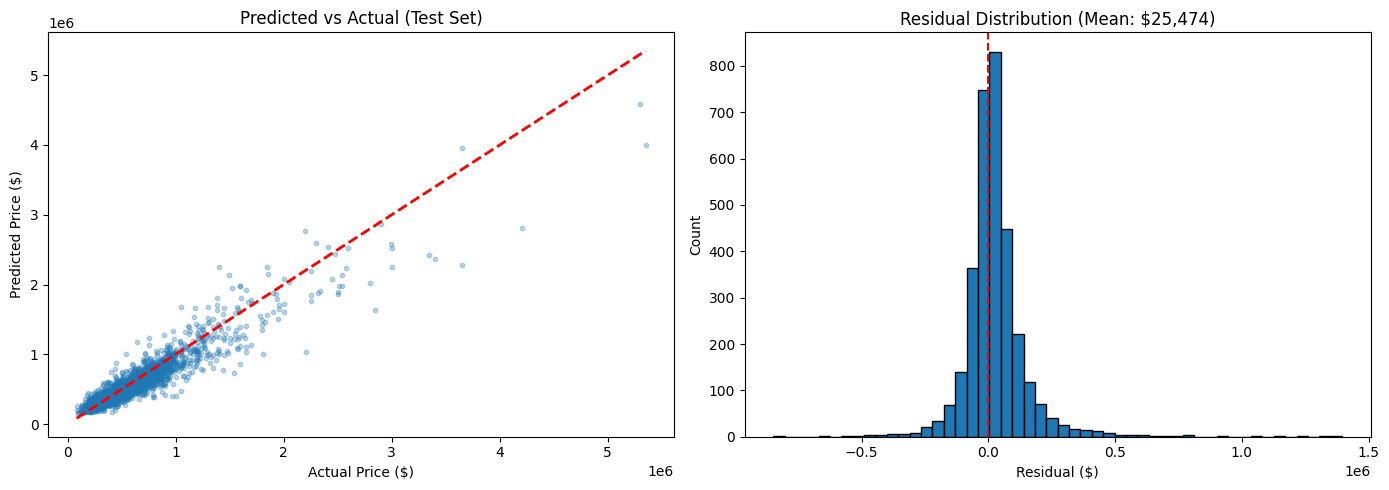

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, test_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs Actual (Test Set)")

# Residuals
residuals = y_test - test_pred
axes[1].hist(residuals, bins=50, edgecolor="black")
axes[1].axvline(x=0, color="r", linestyle="--")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (Mean: ${residuals.mean():,.0f})")

plt.tight_layout()
plt.show()

## Comparison with sklearn models

We load the GradientBoosting model saved in notebook 05 to compare directly on the same test set.

In [ ]:
import pandas as pd
import joblib

gb_model = joblib.load(data_dir / "final_model.joblib")
gb_test_pred = gb_model.predict(X_test)
gb_test_metrics = evaluate_model(y_test, gb_test_pred, "GradientBoosting (Test)")

GradientBoosting (Test):
  RMSE: $134,273
  MAE:  $78,992
  R²:   0.8724
  MAPE: 13.67%


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["RMSE ($)", "MAE ($)", "R²", "MAPE (%)"],
    "GradientBoosting": [
        f"${gb_test_metrics['rmse']:,.0f}",
        f"${gb_test_metrics['mae']:,.0f}",
        f"{gb_test_metrics['r2']:.4f}",
        f"{gb_test_metrics['mape']:.2f}",
    ],
    "Neural Network": [
        f"${nn_test_metrics['rmse']:,.0f}",
        f"${nn_test_metrics['mae']:,.0f}",
        f"{nn_test_metrics['r2']:.4f}",
        f"{nn_test_metrics['mape']:.2f}",
    ],
}).set_index("Metric")

print("Test Set Comparison:")
display(comparison)

Test Set Comparison:


,GradientBoosting,Neural Network
Metric,,
RMSE ($),"$134,273","$131,315"
MAE ($),"$78,992","$77,576"
R²,0.8724,0.8780
MAPE (%),13.67,13.69


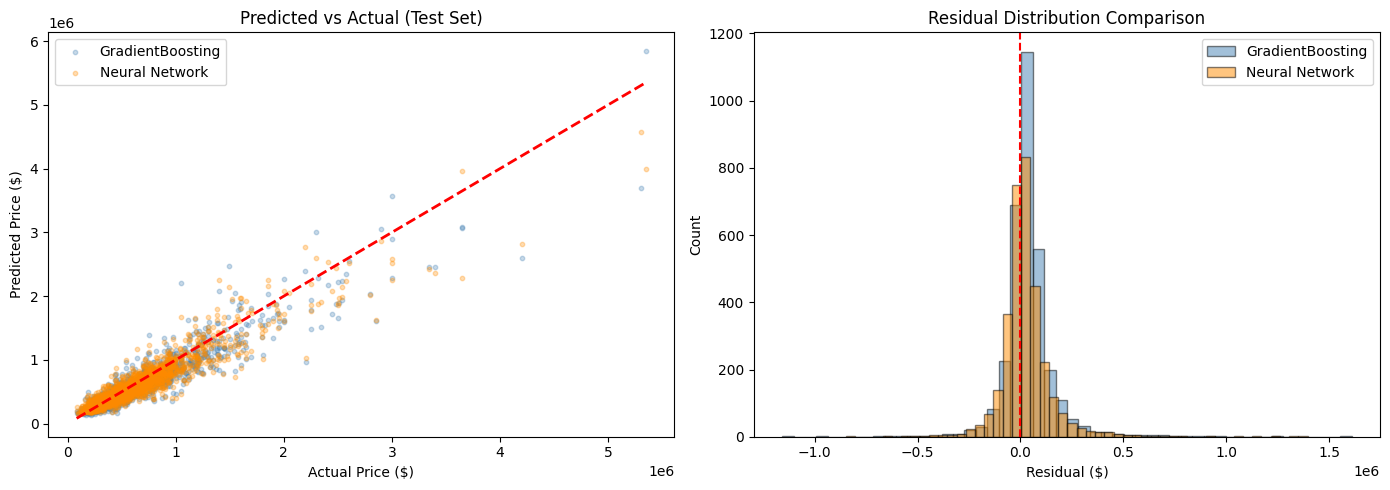

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter comparison: both models
axes[0].scatter(y_test, gb_test_pred, alpha=0.3, s=10, label="GradientBoosting", color="steelblue")
axes[0].scatter(y_test, test_pred, alpha=0.3, s=10, label="Neural Network", color="darkorange")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs Actual (Test Set)")
axes[0].legend()

# Residual comparison
gb_residuals = y_test - gb_test_pred
nn_residuals = y_test - test_pred
axes[1].hist(gb_residuals, bins=50, alpha=0.5, label="GradientBoosting", color="steelblue", edgecolor="black")
axes[1].hist(nn_residuals, bins=50, alpha=0.5, label="Neural Network", color="darkorange", edgecolor="black")
axes[1].axvline(x=0, color="r", linestyle="--")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save the PyTorch model

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "n_features": n_features,
    "architecture": "HousePriceNet",
}, data_dir / "nn_model.pt")

print(f"Model saved to {data_dir / 'nn_model.pt'}")

Model saved to processed_data/nn_model.pt


## Conclusions

**Key takeaways:**

1. **Target scaling is essential for neural networks.** Unlike tree-based models, NNs are sensitive to the scale of the loss gradient. Leaving the target in raw dollars (mean ~$540k, variance ~10¹¹) causes exploding gradients, slow convergence, and spiky loss curves. Scaling to zero mean / unit variance fixes this and is standard practice.

2. **Neural networks are not a silver bullet for tabular data.** On structured/tabular datasets, gradient boosting methods (GradientBoosting, XGBoost, LightGBM) typically match or outperform neural networks. This is well-documented in the literature (e.g., ["Tabular data: Deep learning is not all you need"](https://arxiv.org/abs/2106.03253)).

3. **Neural networks require more engineering effort.** Compared to sklearn's `.fit()`, PyTorch demands explicit training loops, careful hyperparameter selection (learning rate, architecture, dropout, batch size), and monitoring for convergence. The trade-off is full flexibility and the ability to distinguish the optimization signal (MSE loss on scaled target) from the interpretable performance metric (RMSE in dollars).

4. **Two-plot monitoring is more informative than one.** The MSE loss plot reveals convergence behavior (early stopping), while the RMSE-in-dollars plot answers the business question: *how wrong is the model in practice?*

5. **When neural networks *do* shine on tabular data:**
   - Very large datasets (millions of records) where gradient boosting becomes slow
   - When combining tabular data with other modalities (images, text)
   - When entity embeddings can capture categorical variable relationships